# Week 7: Line Plot of IoT Sensor Readings Over Time

**Project:** Smart Logistics Tracking System  
**Company:** Kaizen Logistics  
**Input Dataset:** `assets/cleaned_iot_data.csv`

This notebook visualizes IoT sensor readings from the cleaned blockchain-retrieved dataset prepared in Week 6. The main sensor value is **Temperature**, while **RFID Success %** is included as a tracking reliability indicator. The notebook focuses on clean, professional line plots that use all 100 package records.

## 1. Visualization Objective

The goal of this activity is to create line plots that show how IoT sensor readings change over time. For Kaizen Logistics, the main reading is package **Temperature (°C)**, which supports condition monitoring for perishable and non-perishable shipments.

This notebook includes:

- a full record-level line plot showing all 100 temperature readings,
- temperature trends grouped by package status,
- temperature trends grouped by perishable type,
- RFID tracking reliability over time,
- a dual-axis chart that shows actual temperature and RFID success values together,
- a normalized comparison chart for relative trend comparison.

**Important interpretation note:**  
Actual sensor readings are shown through the non-normalized charts because they preserve the original values such as temperature in °C and RFID success rate in %. Normalized charts are useful only for comparing patterns between indicators with different units.

## 2. Import Required Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set a clean visual theme for professional-looking charts
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

# Improve pandas display readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## 3. Load the Cleaned IoT Dataset

In [2]:
# Load the cleaned IoT dataset from the assets folder.
csv_filename = "cleaned_iot_data.csv"

candidate_paths = [
    Path("assets") / csv_filename,
    Path(csv_filename),
    Path("../assets") / csv_filename
]

csv_path = None
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "cleaned_iot_data.csv was not found. Expected location: assets/cleaned_iot_data.csv"
    )

df = pd.read_csv(csv_path, keep_default_na=False)

print(f"Dataset loaded successfully from: {csv_path}")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully from: assets/cleaned_iot_data.csv
Dataset shape: (100, 34)


,package_id,tracking_number,timestamp,Origin Location,Origin City,Origin Prefecture,Origin Longitude,Origin Latitude,Order Date,Current Location,Estimated Delivery Date,Delivery Exception Reason,Status,Perishable,Temperature,Temperature Issue,Current Longitude,Current Latitude,Delivery Longitude,Delivery Latitude,Delivery City,Delivery Prefecture,Route Distance KM,Estimated Transit Hours,RFID #,RFID Verified,RFID Failure %,RFID Failure Label,RFID Success %,RFID Success Label,Order Week,Estimated Delivery Duration Hours,Delivery Performance,RFID Reliability Category
0,PKG033,KZJP2026000033,2026-05-04 11:51:30.417739,"Ichihara, Chiba",Ichihara,Chiba,140.1109,35.7272,2026-05-03 10:41:01.319632,"Kofu, Yamanashi",2026-05-04 20:13:22.439322,None,Delivered,NO,25.6,Ambient,138.673600,35.721400,138.6736,35.7214,Kofu,Yamanashi,129.75,33.54,RFID-KZ-0033,YES,1.98,Low Risk,98.02,Excellent,"May 3-9, 2026",33.54,Delivered,Excellent
1,PKG023,KZJP2026000023,2026-05-04 19:54:40.370163,"Ureshino, Saga",Ureshino,Saga,130.3639,33.3656,2026-05-03 07:38:33.276989,"Sakaide, Kagawa",2026-05-04 22:43:34.108125,None,Delivered,YES,6.5,Cool,133.976000,34.439800,133.9760,34.4398,Sakaide,Kagawa,354.09,39.08,RFID-KZ-0023,YES,0.91,Low Risk,99.09,Excellent,"May 3-9, 2026",39.08,Delivered,Excellent
2,PKG001,KZJP2026000001,2026-05-05 01:20:39.131540,"Yokote, Akita",Yokote,Akita,140.0319,39.8156,2026-05-03 22:25:43.823106,"Minamisoma, Fukushima",2026-05-05 02:18:47.636072,None,Delivered,NO,16.2,Ambient,140.432800,37.864800,140.4328,37.8648,Minamisoma,Fukushima,219.68,27.88,RFID-KZ-0001,YES,2.66,Low Risk,97.34,Excellent,"May 3-9, 2026",27.88,Delivered,Excellent
3,PKG039,KZJP2026000039,2026-05-05 09:19:14.119968,"Kazuno, Akita",Kazuno,Akita,140.1956,39.6428,2026-05-03 10:32:15.317110,"Hida, Gifu",2026-05-05 12:53:28.111558,None,Delivered,NO,23.1,Ambient,136.764200,35.535500,136.7642,35.5355,Hida,Gifu,547.61,50.35,RFID-KZ-0039,YES,0.92,Low Risk,99.08,Excellent,"May 3-9, 2026",50.35,Delivered,Excellent
4,PKG002,KZJP2026000002,2026-05-05 09:27:46.895510,"Etajima, Hiroshima",Etajima,Hiroshima,132.4169,34.2766,2026-05-04 07:17:03.020266,"Transit Scan near Ogori, Fukuoka",2026-05-06 04:27:51.066871,Shipment still within estimated delivery window,In Transit,YES,5.6,Cool,131.486039,33.920485,130.5200,33.5703,Ogori,Fukuoka,191.83,45.18,RFID-KZ-0002,YES,2.65,Low Risk,97.35,Excellent,"May 3-9, 2026",45.18,In Transit,Excellent


## 4. Check Dataset Structure

In [3]:
# Review available columns and data types before visualization
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBlank values per column:")
blank_counts = df.astype(str).apply(lambda col: col.str.strip().eq("").sum())
print(blank_counts[blank_counts > 0])

Column names:
['package_id', 'tracking_number', 'timestamp', 'Origin Location', 'Origin City', 'Origin Prefecture', 'Origin Longitude', 'Origin Latitude', 'Order Date', 'Current Location', 'Estimated Delivery Date', 'Delivery Exception Reason', 'Status', 'Perishable', 'Temperature', 'Temperature Issue', 'Current Longitude', 'Current Latitude', 'Delivery Longitude', 'Delivery Latitude', 'Delivery City', 'Delivery Prefecture', 'Route Distance KM', 'Estimated Transit Hours', 'RFID #', 'RFID Verified', 'RFID Failure %', 'RFID Failure Label', 'RFID Success %', 'RFID Success Label', 'Order Week', 'Estimated Delivery Duration Hours', 'Delivery Performance', 'RFID Reliability Category']

Data types:
package_id                            object
tracking_number                       object
timestamp                             object
Origin Location                       object
Origin City                           object
Origin Prefecture                     object
Origin Longitude             

## 5. Prepare Date, Time, and Numeric Fields

In [4]:
# Convert timestamp and date fields to datetime format
date_columns = [
    "timestamp",
    "Order Date",
    "Estimated Delivery Date"
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert numeric fields for plotting
numeric_columns = [
    "Temperature",
    "Route Distance KM",
    "Estimated Transit Hours",
    "RFID Failure %",
    "RFID Success %",
    "Estimated Delivery Duration Hours"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Standardize categorical labels
categorical_columns = [
    "Status",
    "Perishable",
    "Temperature Issue",
    "RFID Verified",
    "RFID Failure Label",
    "RFID Success Label",
    "Order Week",
    "Delivery Performance",
    "RFID Reliability Category"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Sort records chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

print("Prepared data shape:", df.shape)
print("\nTemperature range:")
print(df["Temperature"].describe())

print("\nRFID Success % range:")
print(df["RFID Success %"].describe())

df.head()

Prepared data shape: (100, 34)

Temperature range:
count    100.000000
mean      16.706000
std        7.486484
min        2.700000
25%        6.800000
50%       19.100000
75%       22.300000
max       27.900000
Name: Temperature, dtype: float64

RFID Success % range:
count    100.000000
mean      98.140300
std        3.074305
min       75.190000
25%       97.855000
50%       98.530000
75%       99.330000
max       99.840000
Name: RFID Success %, dtype: float64


,package_id,tracking_number,timestamp,Origin Location,Origin City,Origin Prefecture,Origin Longitude,Origin Latitude,Order Date,Current Location,Estimated Delivery Date,Delivery Exception Reason,Status,Perishable,Temperature,Temperature Issue,Current Longitude,Current Latitude,Delivery Longitude,Delivery Latitude,Delivery City,Delivery Prefecture,Route Distance KM,Estimated Transit Hours,RFID #,RFID Verified,RFID Failure %,RFID Failure Label,RFID Success %,RFID Success Label,Order Week,Estimated Delivery Duration Hours,Delivery Performance,RFID Reliability Category
0,PKG033,KZJP2026000033,2026-05-04 11:51:30.417739,"Ichihara, Chiba",Ichihara,Chiba,140.1109,35.7272,2026-05-03 10:41:01.319632,"Kofu, Yamanashi",2026-05-04 20:13:22.439322,None,Delivered,NO,25.6,Ambient,138.673600,35.721400,138.6736,35.7214,Kofu,Yamanashi,129.75,33.54,RFID-KZ-0033,YES,1.98,Low Risk,98.02,Excellent,"May 3-9, 2026",33.54,Delivered,Excellent
1,PKG023,KZJP2026000023,2026-05-04 19:54:40.370163,"Ureshino, Saga",Ureshino,Saga,130.3639,33.3656,2026-05-03 07:38:33.276989,"Sakaide, Kagawa",2026-05-04 22:43:34.108125,None,Delivered,YES,6.5,Cool,133.976000,34.439800,133.9760,34.4398,Sakaide,Kagawa,354.09,39.08,RFID-KZ-0023,YES,0.91,Low Risk,99.09,Excellent,"May 3-9, 2026",39.08,Delivered,Excellent
2,PKG001,KZJP2026000001,2026-05-05 01:20:39.131540,"Yokote, Akita",Yokote,Akita,140.0319,39.8156,2026-05-03 22:25:43.823106,"Minamisoma, Fukushima",2026-05-05 02:18:47.636072,None,Delivered,NO,16.2,Ambient,140.432800,37.864800,140.4328,37.8648,Minamisoma,Fukushima,219.68,27.88,RFID-KZ-0001,YES,2.66,Low Risk,97.34,Excellent,"May 3-9, 2026",27.88,Delivered,Excellent
3,PKG039,KZJP2026000039,2026-05-05 09:19:14.119968,"Kazuno, Akita",Kazuno,Akita,140.1956,39.6428,2026-05-03 10:32:15.317110,"Hida, Gifu",2026-05-05 12:53:28.111558,None,Delivered,NO,23.1,Ambient,136.764200,35.535500,136.7642,35.5355,Hida,Gifu,547.61,50.35,RFID-KZ-0039,YES,0.92,Low Risk,99.08,Excellent,"May 3-9, 2026",50.35,Delivered,Excellent
4,PKG002,KZJP2026000002,2026-05-05 09:27:46.895510,"Etajima, Hiroshima",Etajima,Hiroshima,132.4169,34.2766,2026-05-04 07:17:03.020266,"Transit Scan near Ogori, Fukuoka",2026-05-06 04:27:51.066871,Shipment still within estimated delivery window,In Transit,YES,5.6,Cool,131.486039,33.920485,130.5200,33.5703,Ogori,Fukuoka,191.83,45.18,RFID-KZ-0002,YES,2.65,Low Risk,97.35,Excellent,"May 3-9, 2026",45.18,In Transit,Excellent


## 6. Set Visualization Colors and Formatting

In [5]:
# Consistent color palettes
status_order = ["Delivered", "In Transit", "Not Delivered"]
status_order = [status for status in status_order if status in df["Status"].unique()]

status_palette = {
    "Delivered": "#2E7D32",
    "In Transit": "#1976D2",
    "Not Delivered": "#C62828"
}

perishable_palette = {
    "YES": "#00897B",
    "NO": "#6A1B9A"
}

temperature_issue_palette = {
    "Cool": "#0288D1",
    "Ambient": "#43A047",
    "Danger Zone": "#D32F2F"
}

sensor_palette = {
    "Temperature (°C)": "#E76F51",
    "RFID Success (%)": "#457B9D"
}

def apply_datetime_axis(ax, minticks=6, maxticks=10):
    """
    Apply readable date and time labels to a matplotlib axis.
    """
    locator = mdates.AutoDateLocator(minticks=minticks, maxticks=maxticks)
    formatter = mdates.DateFormatter("%b %d\n%H:%M")
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

def polish_line_chart(ax, title, xlabel, ylabel, legend_title=None):
    """
    Apply standard formatting to line plots.
    """
    ax.set_title(title, fontsize=17, fontweight="bold", pad=15)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.30)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if legend_title is not None:
        ax.legend(
            title=legend_title,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0
        )

    plt.tight_layout()

## 7. IoT Sensor Readings Over Time: All 100 Package Temperature Records

This chart uses all 100 package records from the cleaned dataset. Each point represents one package temperature reading. The y-axis uses the actual sensor value in degrees Celsius, making this the most direct chart for logistics interpretation.

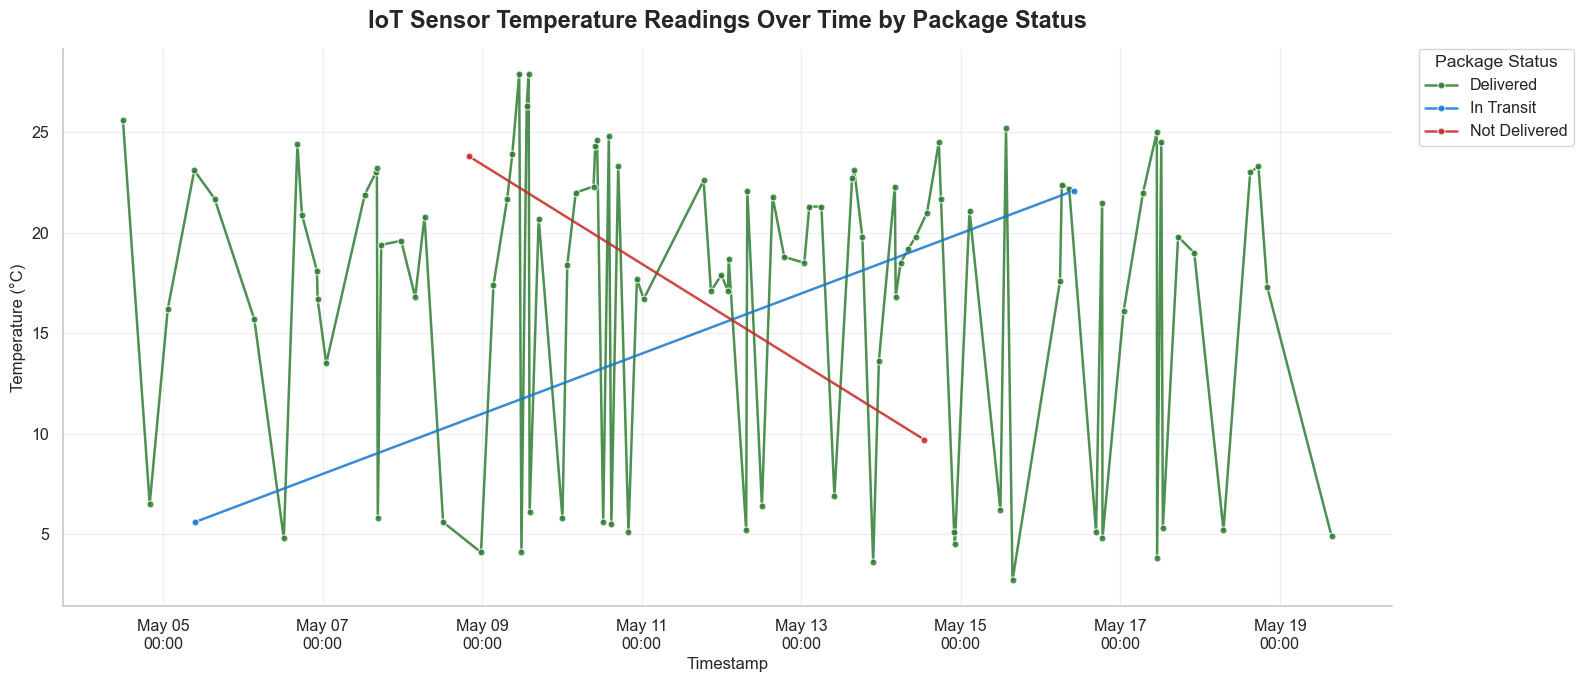

Total plotted data points: 100


In [6]:
# Show all 100 package temperature records over time by status
fig, ax = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df,
    x="timestamp",
    y="Temperature",
    hue="Status",
    hue_order=status_order,
    palette=status_palette,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    alpha=0.85,
    ax=ax
)

apply_datetime_axis(ax, minticks=7, maxticks=12)

polish_line_chart(
    ax=ax,
    title="IoT Sensor Temperature Readings Over Time by Package Status",
    xlabel="Timestamp",
    ylabel="Temperature (°C)",
    legend_title="Package Status"
)

plt.show()

print("Total plotted data points:", len(df))

## 8. IoT Sensor Temperature Over Time by Perishable Type

This chart compares actual temperature readings between perishable and non-perishable packages. It helps show whether perishable shipments are kept under more controlled temperature conditions.

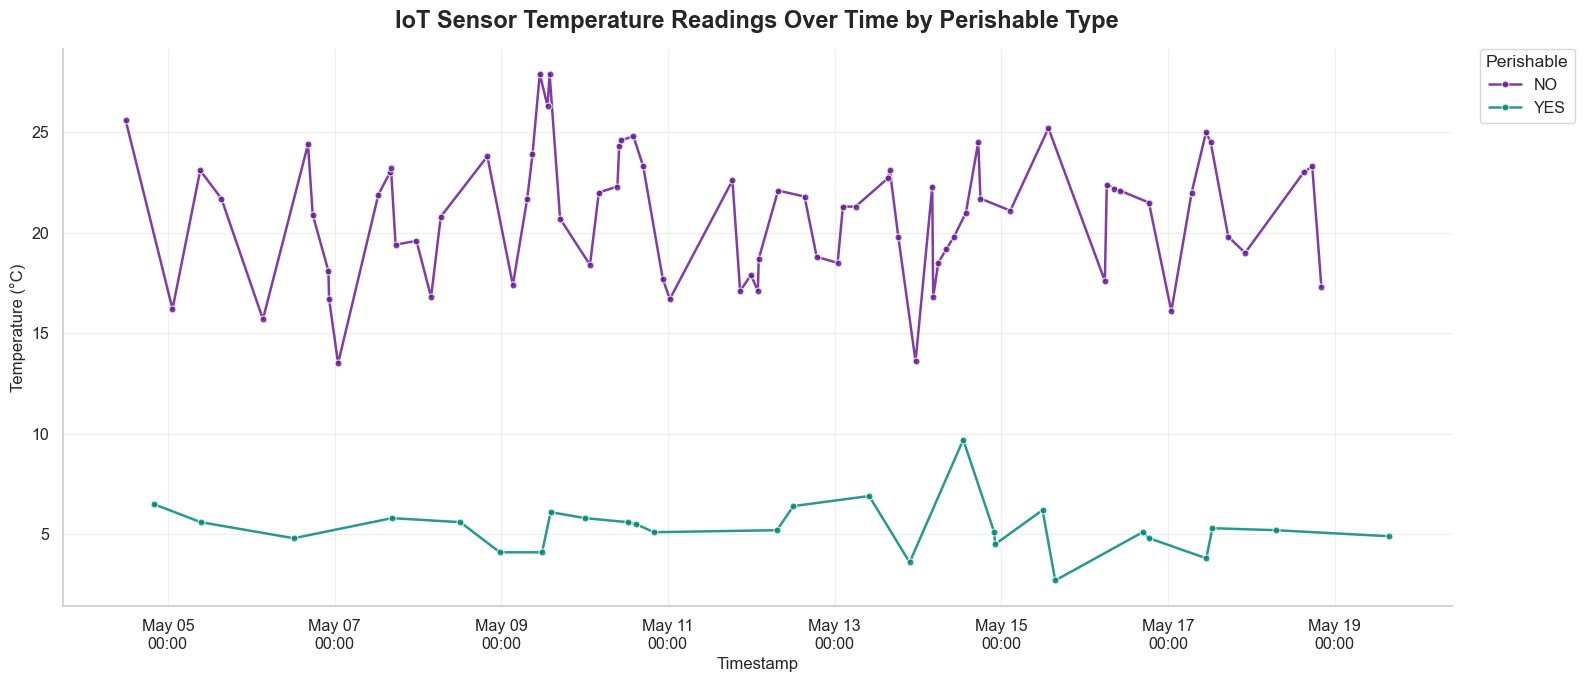

In [7]:
fig, ax = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df,
    x="timestamp",
    y="Temperature",
    hue="Perishable",
    palette=perishable_palette,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    alpha=0.85,
    ax=ax
)

apply_datetime_axis(ax, minticks=7, maxticks=12)

polish_line_chart(
    ax=ax,
    title="IoT Sensor Temperature Readings Over Time by Perishable Type",
    xlabel="Timestamp",
    ylabel="Temperature (°C)",
    legend_title="Perishable"
)

plt.show()

## 9. IoT Sensor Temperature Over Time by Temperature Issue

This chart groups actual temperature readings based on their condition classification. It helps show the separation between `Cool`, `Ambient`, and `Danger Zone` package conditions.

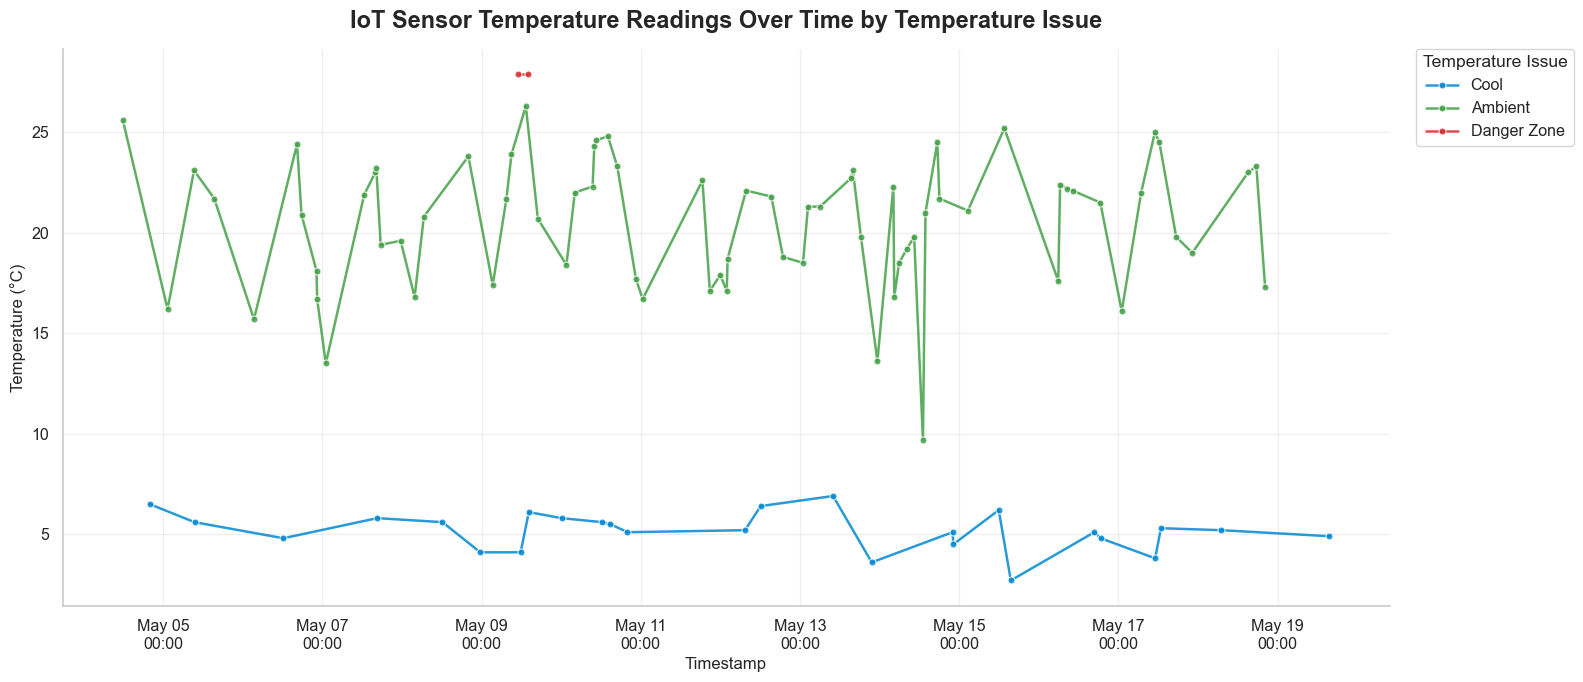

In [8]:
temperature_issue_order = [label for label in ["Cool", "Ambient", "Danger Zone"] if label in df["Temperature Issue"].unique()]

fig, ax = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df,
    x="timestamp",
    y="Temperature",
    hue="Temperature Issue",
    hue_order=temperature_issue_order,
    palette=temperature_issue_palette,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    alpha=0.85,
    ax=ax
)

apply_datetime_axis(ax, minticks=7, maxticks=12)

polish_line_chart(
    ax=ax,
    title="IoT Sensor Temperature Readings Over Time by Temperature Issue",
    xlabel="Timestamp",
    ylabel="Temperature (°C)",
    legend_title="Temperature Issue"
)

plt.show()

## 10. IoT Tracking Reliability Over Time: RFID Success Rate

RFID success rate is not a temperature sensor reading, but it is a key IoT tracking reliability indicator. This chart shows the actual RFID success percentage over time.

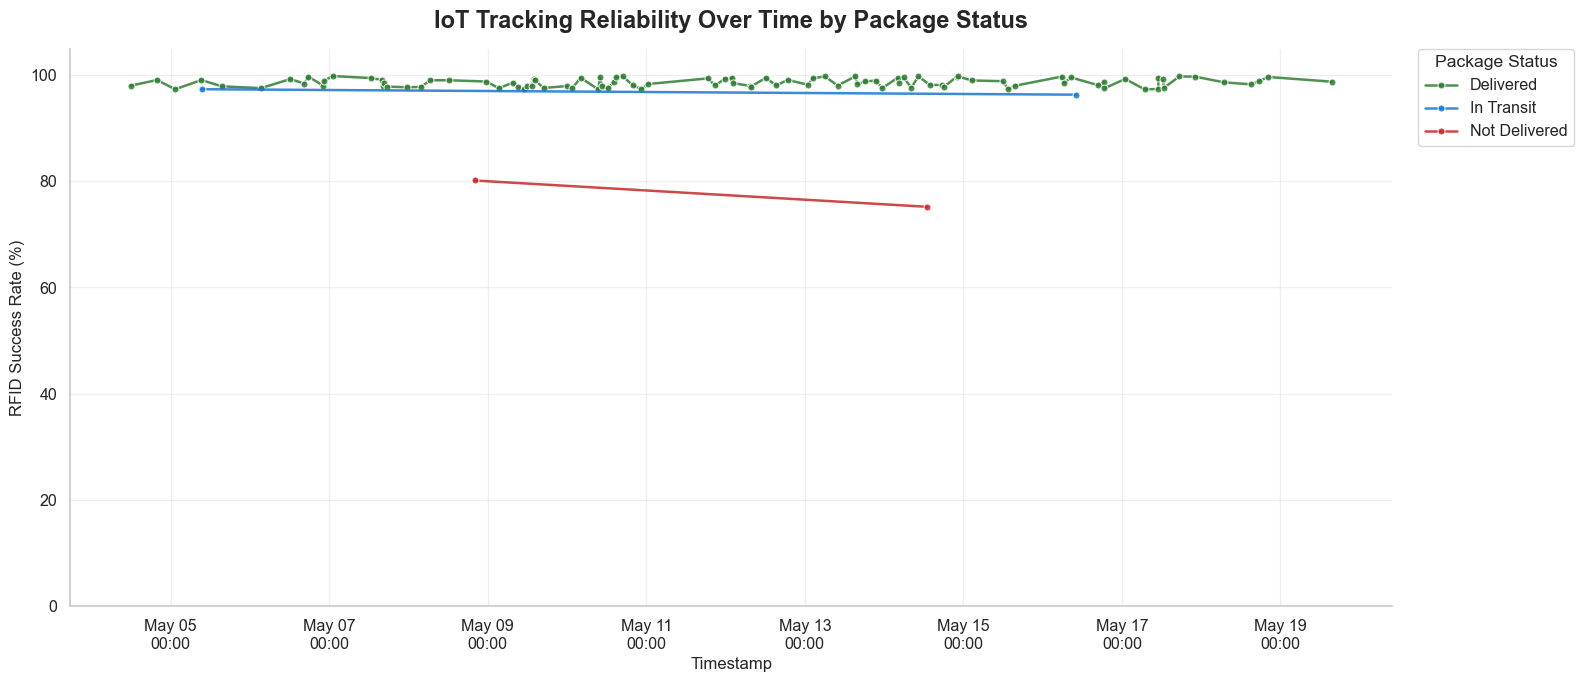

In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df,
    x="timestamp",
    y="RFID Success %",
    hue="Status",
    hue_order=status_order,
    palette=status_palette,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    alpha=0.85,
    ax=ax
)

apply_datetime_axis(ax, minticks=7, maxticks=12)

polish_line_chart(
    ax=ax,
    title="IoT Tracking Reliability Over Time by Package Status",
    xlabel="Timestamp",
    ylabel="RFID Success Rate (%)",
    legend_title="Package Status"
)

ax.set_ylim(0, 105)

plt.show()

## 11. Actual Sensor and Tracking Values Together: Dual-Axis Line Plot

A dual-axis chart allows the notebook to show actual values for two different units at the same time: **Temperature (°C)** on the left axis and **RFID Success Rate (%)** on the right axis. This preserves the real sensor readings without normalizing them.

This is the best approach when the goal is to compare two indicators while still keeping their actual units visible.

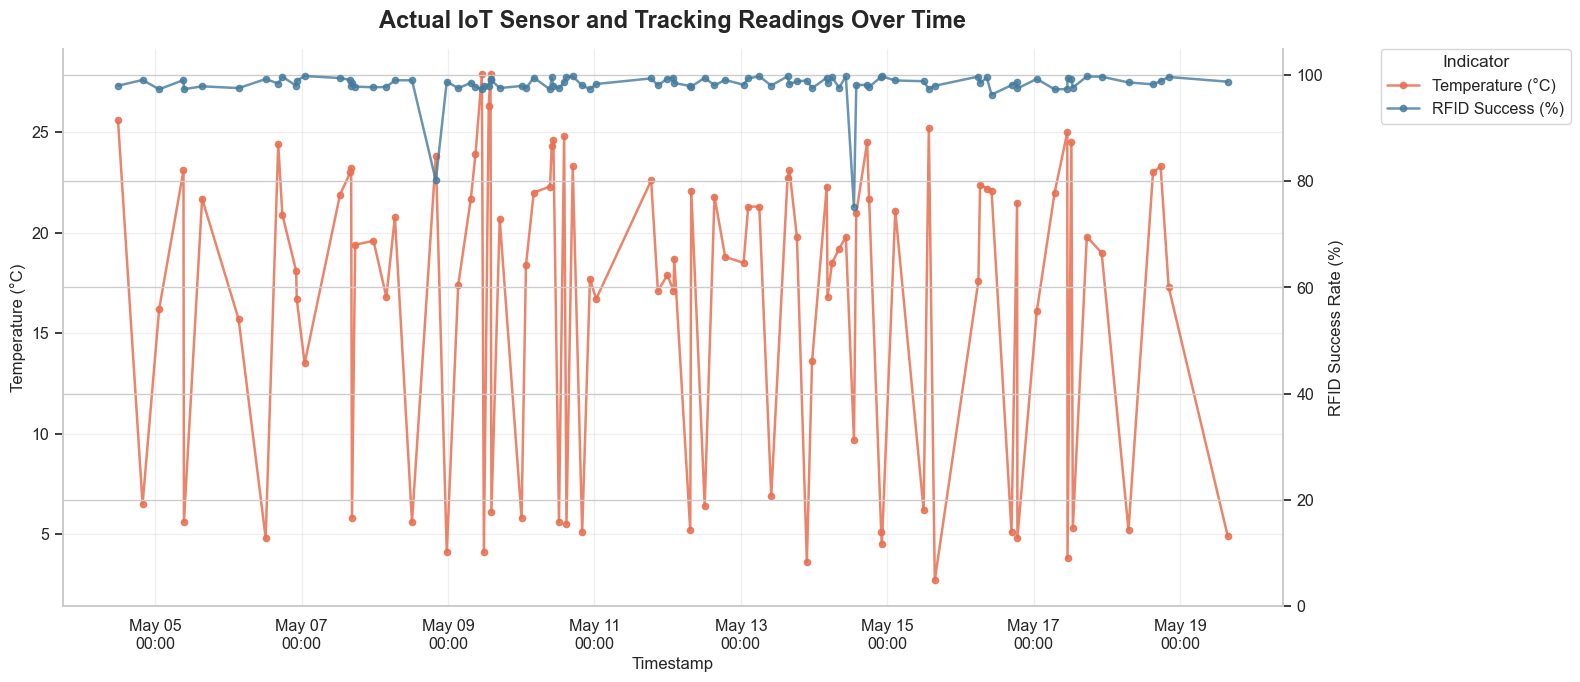

In [10]:
# Create an actual-value dual-axis line chart
fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.plot(
    df["timestamp"],
    df["Temperature"],
    marker="o",
    markersize=4.5,
    linewidth=1.8,
    alpha=0.85,
    color=sensor_palette["Temperature (°C)"],
    label="Temperature (°C)"
)

ax1.set_ylabel("Temperature (°C)", fontsize=12)
ax1.tick_params(axis="y")

ax2 = ax1.twinx()

ax2.plot(
    df["timestamp"],
    df["RFID Success %"],
    marker="o",
    markersize=4.5,
    linewidth=1.8,
    alpha=0.80,
    color=sensor_palette["RFID Success (%)"],
    label="RFID Success (%)"
)

ax2.set_ylabel("RFID Success Rate (%)", fontsize=12)
ax2.set_ylim(0, 105)

apply_datetime_axis(ax1, minticks=7, maxticks=12)

ax1.set_title("Actual IoT Sensor and Tracking Readings Over Time", fontsize=17, fontweight="bold", pad=15)
ax1.set_xlabel("Timestamp", fontsize=12)
ax1.grid(True, alpha=0.30)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    title="Indicator",
    bbox_to_anchor=(1.08, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 12. Normalized IoT Indicator Comparison

Normalization scales both indicators between 0 and 1. This is useful for comparing relative movement patterns between temperature and RFID success rate. However, the values no longer represent actual °C or % readings, so this chart should be treated as a supporting view.

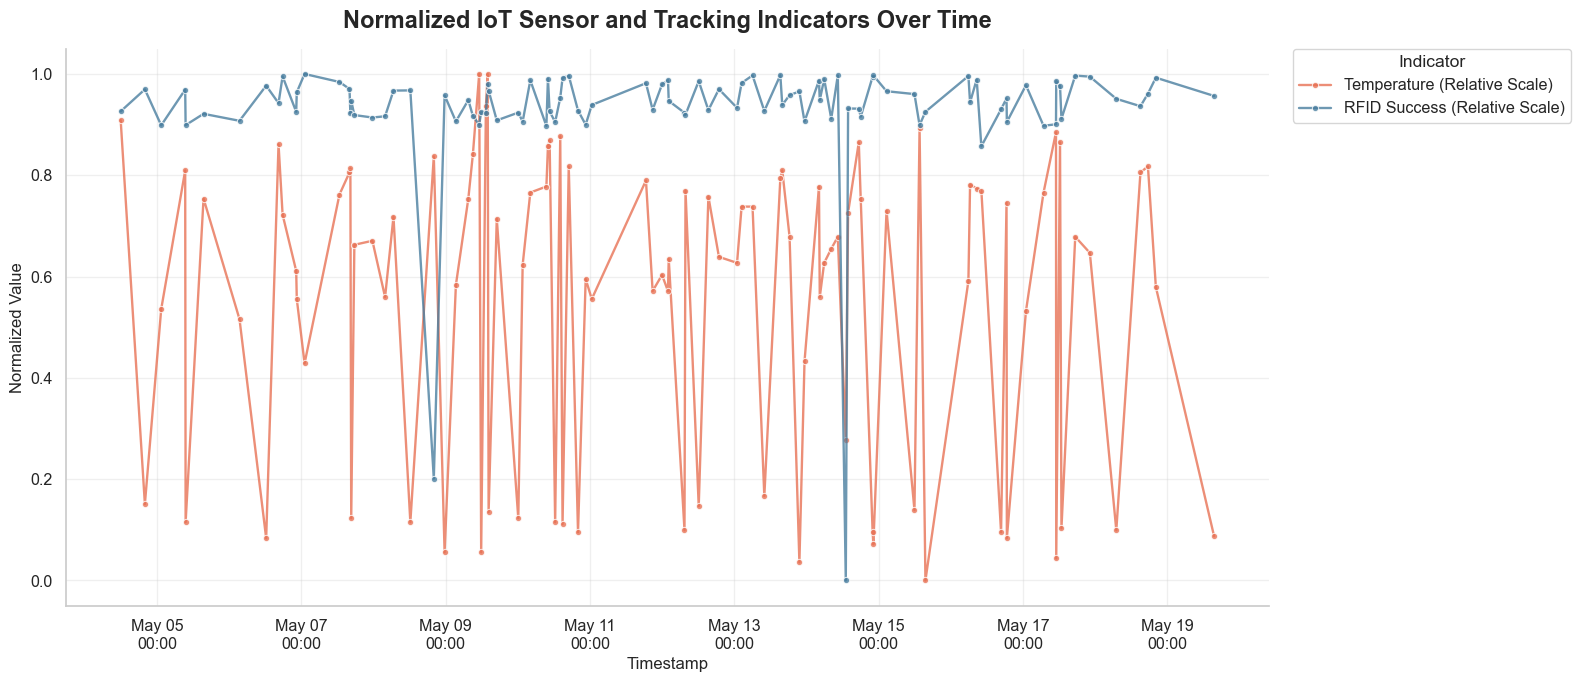

Normalization reference values:
Temperature: min=2.70, max=27.90
RFID Success %: min=75.19, max=99.84


In [11]:
# Create normalized values for comparison
normalized_df = df.copy()

sensor_columns = ["Temperature", "RFID Success %"]

for col in sensor_columns:
    min_value = normalized_df[col].min()
    max_value = normalized_df[col].max()

    if max_value == min_value:
        normalized_df[f"Normalized {col}"] = 0
    else:
        normalized_df[f"Normalized {col}"] = (normalized_df[col] - min_value) / (max_value - min_value)

normalized_long = normalized_df.melt(
    id_vars=["timestamp", "package_id", "Status"],
    value_vars=["Normalized Temperature", "Normalized RFID Success %"],
    var_name="Sensor Indicator",
    value_name="Normalized Value"
)

normalized_long["Sensor Indicator"] = normalized_long["Sensor Indicator"].replace({
    "Normalized Temperature": "Temperature (Relative Scale)",
    "Normalized RFID Success %": "RFID Success (Relative Scale)"
})

normalized_palette = {
    "Temperature (Relative Scale)": "#E76F51",
    "RFID Success (Relative Scale)": "#457B9D"
}

fig, ax = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=normalized_long,
    x="timestamp",
    y="Normalized Value",
    hue="Sensor Indicator",
    palette=normalized_palette,
    marker="o",
    markersize=4.5,
    linewidth=1.7,
    estimator=None,
    alpha=0.78,
    ax=ax
)

apply_datetime_axis(ax, minticks=7, maxticks=12)

polish_line_chart(
    ax=ax,
    title="Normalized IoT Sensor and Tracking Indicators Over Time",
    xlabel="Timestamp",
    ylabel="Normalized Value",
    legend_title="Indicator"
)

plt.show()

print("Normalization reference values:")
for col in sensor_columns:
    print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}")

## 13. Aggregated Temperature Trend with Confidence Interval

This plot summarizes temperature readings by date and package status. The confidence interval provides a cleaner presentation-level view of the general trend, while the previous record-level plots show all package readings.

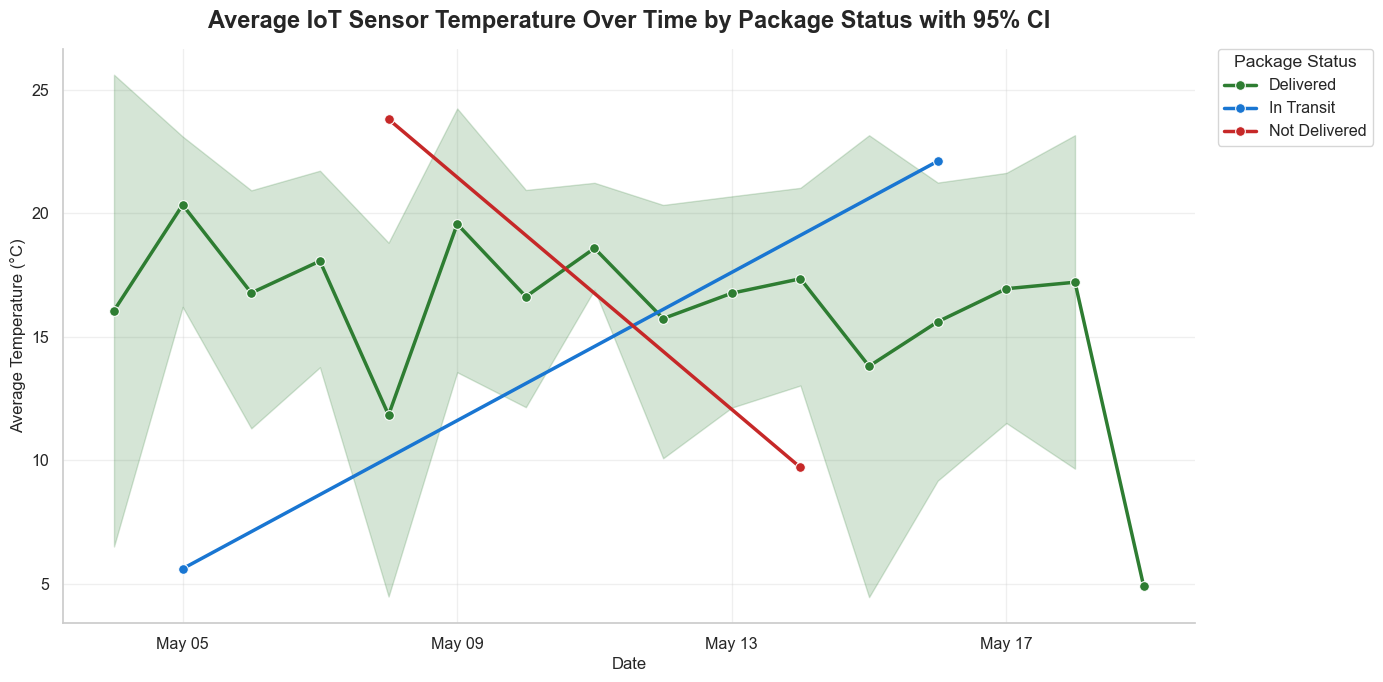

In [12]:
# Create date-only field for cleaner aggregated plotting
df["Date"] = df["timestamp"].dt.date
df["Date"] = pd.to_datetime(df["Date"])

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=df,
    x="Date",
    y="Temperature",
    hue="Status",
    hue_order=status_order,
    palette=status_palette,
    estimator="mean",
    errorbar=("ci", 95),
    marker="o",
    markersize=7,
    linewidth=2.5,
    ax=ax
)

locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

polish_line_chart(
    ax=ax,
    title="Average IoT Sensor Temperature Over Time by Package Status with 95% CI",
    xlabel="Date",
    ylabel="Average Temperature (°C)",
    legend_title="Package Status"
)

plt.show()

## 14. Visualization Notes

The **non-normalized temperature charts** are the recommended primary visuals because they show the actual sensor readings in degrees Celsius. These are easiest to explain in a logistics context.

The **dual-axis chart** is recommended when presenting temperature and RFID success together because it keeps both values in their real units.

The **normalized chart** is useful only as a supporting comparison because it highlights relative movement but does not show actual °C or % values.